# Evaluation

Compare No-RAG (baseline) vs RAG modes. Produce token-usage charts and simple quality proxies (response length).

In [7]:
import json, statistics
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

baseline_path = PROJECT_ROOT / 'notebooks' / 'baseline_no_rag_results.json'
rag_path = PROJECT_ROOT / 'notebooks' / 'rag_pipeline_results.json'

def safe_load_json(path: Path):
    if not path.exists():
        return None
    text = path.read_text(encoding='utf8')
    if not text or not text.strip():
        return None
    try:
        return json.loads(text)
    except Exception as e:
        # try to extract first JSON array or object from file
        start = text.find('[')
        end = text.rfind(']')
        if start != -1 and end != -1 and end > start:
            try:
                return json.loads(text[start:end+1])
            except Exception:
                pass
        start = text.find('{')
        end = text.rfind('}')
        if start != -1 and end != -1 and end > start:
            try:
                return json.loads(text[start:end+1])
            except Exception:
                pass
        print(f'Warning: failed to parse JSON from {path}: {e}')
        return None

baseline = safe_load_json(baseline_path) or []
rag = safe_load_json(rag_path) or {}

# normalize rag structure for easy access
rag_modes = { 'bm25': rag.get('bm25', []), 'vector': rag.get('vector', []), 'hybrid': rag.get('hybrid', []) }

def avg_response_tokens(items):
    if not items:
        return 0
    return statistics.mean(it['response_tokens'] for it in items)

print('Baseline queries:', len(baseline))
for m, items in rag_modes.items():
    print(f'{m}: {len(items)} queries')

print('\nAverage response tokens (approx):')
print('baseline:', avg_response_tokens(baseline))
for m in rag_modes:
    print(m + ':', avg_response_tokens(rag_modes[m]))

Baseline queries: 5
bm25: 5 queries
vector: 5 queries
hybrid: 5 queries

Average response tokens (approx):
baseline: 19.8
bm25: 53.2
vector: 52.4
hybrid: 52


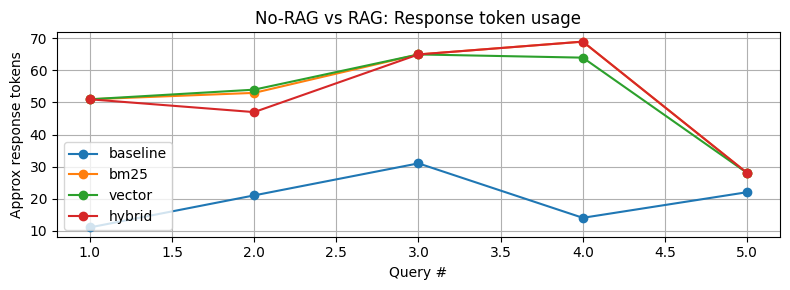

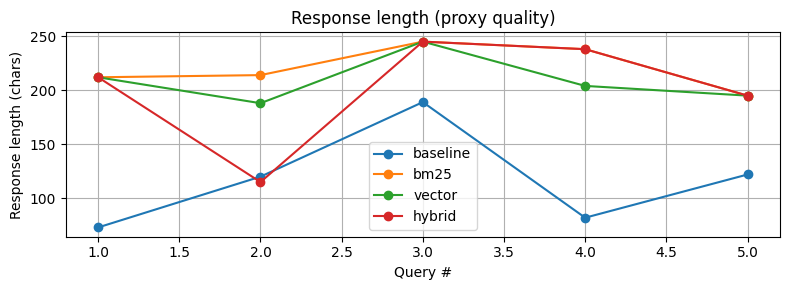

In [8]:
import matplotlib.pyplot as plt

# token usage comparison (response tokens)
plt.figure(figsize=(8,3))
if baseline:
    plt.plot(list(range(1,len(baseline)+1)), [b['response_tokens'] for b in baseline], marker='o', label='baseline')
for m in rag_modes:
    items = rag_modes[m]
    if items:
        plt.plot(list(range(1,len(items)+1)), [it['response_tokens'] for it in items], marker='o', label=m)
plt.xlabel('Query #')
plt.ylabel('Approx response tokens')
plt.title('No-RAG vs RAG: Response token usage')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# simple proxy for content change: response length in characters
plt.figure(figsize=(8,3))
if baseline:
    plt.plot(list(range(1,len(baseline)+1)), [len(b['response']) for b in baseline], marker='o', label='baseline')
for m in rag_modes:
    items = rag_modes[m]
    if items:
        plt.plot(list(range(1,len(items)+1)), [len(it['response']) for it in items], marker='o', label=m)
plt.xlabel('Query #')
plt.ylabel('Response length (chars)')
plt.title('Response length (proxy quality)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Next steps
- Run the two notebooks to produce results files.
- Optionally expand evaluation with LLM-as-judge comparisons or human grading.